In [ ]:
pip install refractiveindex

Note: you may need to restart the kernel to use updated packages.


### Data
- Database denoted as $\tilde{n}$
- Represents two distinct physical properties in one complex number: $\tilde{n} = n + i\kappa$

In [1]:
from refractiveindex import RefractiveIndexMaterial

# Example: Get data for Silicon (Shelf: main, Book: Si, Page: Aspnes)
# Note: You can find these names in the URL of the material on the website.
silicon = RefractiveIndexMaterial(shelf='main', book='Si', page='Aspnes')

# Get Refractive Index (n) and Extinction Coefficient (k) at 550nm
wavelength_nm = 550
n = silicon.get_refractive_index(wavelength_nm)
k = silicon.get_extinction_coefficient(wavelength_nm)

N = complex(n, k)

print(f"Silicon at {wavelength_nm}nm: n={n}, k={k}, N={N}")

Silicon at 550nm: n=4.086963265306123, k=0.0408816326530612, N=(4.086963265306123+0.0408816326530612j)


### n (real)
- Speed (Phase Velocity):  It tells you how much the material slows down light. $v = \frac{c}{n}  \rightarrow n = \frac{c}{v}$
- Opacity and Bending (refraction): It dictates how much light bends(refracts) when entering the material(medium) (Snell's Law). 
    - A higher n means more bending and slower velocity
- I need to look at group velocity

In [ ]:
from scipy.constants import c
from refractiveindex import RefractiveIndexMaterial

silicon = RefractiveIndexMaterial(shelf='main', book='Si', page='Aspnes')

wavelength_nm = 550
n = silicon.get_refractive_index(wavelength_nm)

print(c)  # 299792458.0 m/s

velocity = c / n 

# phase velocity given K = 0
# else we need to look at c / n_g where n_g =  n- (lamda * dn/dlamda)

print(velocity)

299792458.0
73353352.73133287


### Snell's Law
- how much the direction of light bends when it moves from one material into another
    $$N_1 \sin(\theta_1) = N_2 \sin(\theta_2)$$
    - $N_1$: Refractive index, intial material $n_2$: Refractive index, target material
        - $N_1 N_2$ can be complex remember 𝑁 = 𝑛 + 𝑖𝑘
        - where n is real and ik is complex  
    - $\theta_1$: Input angle (Incident Angle). $\theta_2$: Output angle (Refracted Angle). This is what you are solving for
- Database: get_refractive_index(0.55) $\to$ returns $n_2 = 1.5$ (Glass).
- Input $\theta_1$: $45^\circ$ L.I.G.O. Angle
- Snell's Law $\to$ new angle $\theta_2$ inside the glass
    $$1 \sin(45°) = 1.5 \sin(\theta_2)$$
    $$\theta_2 = \sin^{-1}\left(\frac{1}{1.5} \sin(45^\circ)\right)$$
  - Water ($n \approx 1.33$): Angle becomes 32.1°. (Bends a little)
  - Glass ($n \approx 1.52$): Angle becomes 27.7°. (Bends more)
  - Diamond ($n \approx 2.42$): Angle becomes 17.0°. (Bends heavily)
  - closer together less bending further more bending
  - small amount of light is reflected depending on refractive index

In [ ]:
from refractiveindex import RefractiveIndexMaterial
import math
import cmath  # Use cmath for complex numbers

silicon = RefractiveIndexMaterial(shelf='main', book='Si', page='Aspnes')
tantalum = RefractiveIndexMaterial(shelf='main', book='Ta', page='Werner')

wavelength_nm = 550

# This is the real componet n and we are assuming k = 0 for simplicity
#n2 = tantalum.get_refractive_index(wavelength_nm)
n1 = 1 #air
n3 = silicon.get_refractive_index(wavelength_nm)
n2 = tantalum.get_refractive_index(wavelength_nm)

#si->ta->ta is complex, ta->si->ta is not, air(1)->si->ta is not

theta1_deg = 45
theta1_rad = math.radians(theta1_deg)

# Snell's law: sin(theta2) = (n1 / n2) * sin(theta1)
argument = (n1 / n2) * math.sin(theta1_rad)

# Use cmath.asin for complex arguments
theta2_rad = cmath.asin(argument)
theta2_deg = theta2_rad * (180 / math.pi)

argument1 = (n2 / n3) * cmath.sin(theta2_rad)

theta3_rad = cmath.asin(argument1)
theta3_deg = theta3_rad * (180 / math.pi)

print(f"Refractive Index Si: {n1:.3f}")
print(f"Refractive Index Ta: {n2:.3f}")
print(f"Complex Angle (rad): {theta2_rad}")
print(f"Complex Angle (deg): {theta2_deg}")
print(f"Complex Angle (rad): {theta3_rad}")
print(f"Complex Angle (deg): {theta3_deg}")

Refractive Index Si: 1.000
Refractive Index Ta: 1.121
Complex Angle (rad): (0.6823750631633622+0j)
Complex Angle (deg): (39.09721116423362+0j)
Complex Angle (rad): (0.17389022279424765+0j)
Complex Angle (deg): (9.963175864699975+0j)


### k (imaginary)
- material.get_extinction_coefficient(wavelength) will return the value k
### Representation
- Absorption:  This measures how quickly light "dies", absorbed, as it travels through the material.
- If k ≈ 0, the material is transparent
- If k > 0, the material absorbs light
- Example: 
    - Silicon has a very high refractive index (n = 4.08), so it reflects a lot of light. 
    - However, the k = 0.03 means it also absorbs light. 
    - If you make a Silicon wafer thick enough, no light gets through.
- k tells you how much of direction/velocity change of light, n, is absorbed, not transmitted 
- by adding the real component of transmitted and complex of absorbed we get the full amount of light traveled

In [1]:
from refractiveindex import RefractiveIndexMaterial
import math, cmath

# Example materials
silicon = RefractiveIndexMaterial(shelf='main', book='Si', page='Aspnes')
tantalum = RefractiveIndexMaterial(shelf='main', book='Ta', page='Werner')

wavelength_nm = 550
theta1_deg = 45
theta1_rad = math.radians(theta1_deg)

# Build complex indices N = n + i k
n1 = silicon.get_refractive_index(wavelength_nm)
k1 = silicon.get_extinction_coefficient(wavelength_nm)
N1 = complex(n1, k1)

n2 = tantalum.get_refractive_index(wavelength_nm)
k2 = tantalum.get_extinction_coefficient(wavelength_nm)
N2 = complex(n2, k2)

# Complex Snell
argument = (N1 / N2) * math.sin(theta1_rad)

# Use cmath.asin for complex arguments
theta2_rad = cmath.asin(argument)
theta2_deg = theta2_rad * (180 / math.pi)

print("N1 =", N1)
print("N2 =", N2)
print("theta2 (rad) =", theta2_rad)
print("theta2 (deg) =", theta2_deg)


N1 = (4.086963265306123+0.0408816326530612j)
N2 = (1.1212561628919862+4.883463294860627j)
theta2 (rad) = (0.11755226629769405-0.538362893027212j)
theta2 (deg) = (6.735248731055816-30.84592161691226j)


In [22]:
import math
import cmath
from refractiveindex import RefractiveIndexMaterial

def complex_index(material, wavelength_nm):
    n = material.get_refractive_index(wavelength_nm)
    k = material.get_extinction_coefficient(wavelength_nm)
    return complex(n, k)

def kz_from_kpar(k0, N, kpar):
    kz = cmath.sqrt((k0 * N)**2 - kpar**2)
    # Choose physical branch: decay for +z (Im(kz) >= 0)
    if kz.imag < 0:
        kz = -kz
    return kz

def fresnel_r_from_kz(Ni, Nj, kzi, kzj):
    """
    Returns (rs, rp) for interface i->j in terms of kz.
    Valid for non-magnetic media (mu_r ~ 1).
    """
    # s (TE): rs = (Ni cosθi - Nj cosθj)/(Ni cosθi + Nj cosθj)
    # but Ni cosθi = kzi/k0, Nj cosθj = kzj/k0  => rs = (kzi - kzj)/(kzi + kzj)
    rs = (kzi - kzj) / (kzi + kzj)

    # p (TM): rp = (Nj cosθi - Ni cosθj)/(Nj cosθi + Ni cosθj)
    # => rp = (Nj^2 kzi - Ni^2 kzj)/(Nj^2 kzi + Ni^2 kzj)
    rp = (Nj**2 * kzi - Ni**2 * kzj) / (Nj**2 * kzi + Ni**2 * kzj)
    return rs, rp

def total_reflection_single_film(N0, N1, N2, kz0, kz1, kz2, d1_m, k0):
    """
    air (0) | film (1 thickness d1) | substrate (2 semi-infinite)
    Returns (R_s, R_p) at the entrance.
    """
    r01_s, r01_p = fresnel_r_from_kz(N0, N1, kz0, kz1)
    r12_s, r12_p = fresnel_r_from_kz(N1, N2, kz1, kz2)

    phase = cmath.exp(2j * kz1 * d1_m)  # includes decay if kz1 is complex

    rtot_s = (r01_s + r12_s * phase) / (1 + r01_s * r12_s * phase)
    rtot_p = (r01_p + r12_p * phase) / (1 + r01_p * r12_p * phase)

    R_s = abs(rtot_s)**2
    R_p = abs(rtot_p)**2
    return R_s, R_p

# --- Materials ---
silicon = RefractiveIndexMaterial(shelf='main', book='Si', page='Aspnes')
tantalum = RefractiveIndexMaterial(shelf='main', book='Ta', page='Werner')

wavelength_nm = 550
theta0_deg = 45.0

# Complex indices
N0 = 1.0 + 0.0j                  # air
N1 = complex_index(silicon, wavelength_nm)
N2 = complex_index(tantalum, wavelength_nm)

# Wave numbers
lam_m = wavelength_nm * 1e-9
k0 = 2 * math.pi / lam_m
theta0 = math.radians(theta0_deg)

kpar = k0 * N0 * math.sin(theta0)  # conserved (complex if N0 complex)

kz0 = kz_from_kpar(k0, N0, kpar)
kz1 = kz_from_kpar(k0, N1, kpar)
kz2 = kz_from_kpar(k0, N2, kpar)

print("Indices:")
print("N0 (air) =", N0)
print("N1 (Si)  =", N1)
print("N2 (Ta)  =", N2)
print()
print("k_parallel =", kpar)
print("kz0 =", kz0)
print("kz1 =", kz1)
print("kz2 =", kz2)

# Optional: interface Fresnel r's
r01_s, r01_p = fresnel_r_from_kz(N0, N1, kz0, kz1)
r12_s, r12_p = fresnel_r_from_kz(N1, N2, kz1, kz2)
print()
print("Interface reflection amplitudes:")
print("r01_s =", r01_s, " | r01_p =", r01_p)
print("r12_s =", r12_s, " | r12_p =", r12_p)

# Optional: total reflection of the 3-layer system (needs film thickness)
d1_nm = 100.0  # <-- choose your Si film thickness
d1_m = d1_nm * 1e-9

R_s, R_p = total_reflection_single_film(N0, N1, N2, kz0, kz1, kz2, d1_m, k0)
R_unpol = 0.5 * (R_s + R_p)
print()
print(f"Total reflectance for air|Si({d1_nm} nm)|Ta at {theta0_deg}°:")
print(f"R_s = {100*R_s:.3f}%  R_p = {100*R_p:.3f}%  R_unpol = {100*R_unpol:.3f}%")


Indices:
N0 (air) = (1+0j)
N1 (Si)  = (4.086963265306123+0.0408816326530612j)
N2 (Ta)  = (1.1212561628919862+4.883463294860627j)

k_parallel = (8077968.978469756+0j)
kz0 = (8077968.9784697555+0j)
kz1 = (45985317.2890104+474180.9867095574j)
kz2 = (12683399.231338464+56341897.065331206j)

Interface reflection amplitudes:
r01_s = (-0.7011891742645935-0.0026208249991629073j)  | r01_p = (0.49165938938218595+0.0036753882341100884j)
r12_s = (-0.18296674224219903-0.7750683169400764j)  | r12_p = (0.14404561691941076+0.7749442478095312j)

Total reflectance for air|Si(100.0 nm)|Ta at 45.0°:
R_s = 69.359%  R_p = 55.353%  R_unpol = 62.356%


N1 = (4.086963265306123+0.0408816326530612j)
N2 = (1.5185223876207927+7.235011764705884e-09j)
theta2 (rad) = (1.559040385436875+1.2592016587400676j)
theta2 (deg) = (89.32643417598207+72.14694060167845j)


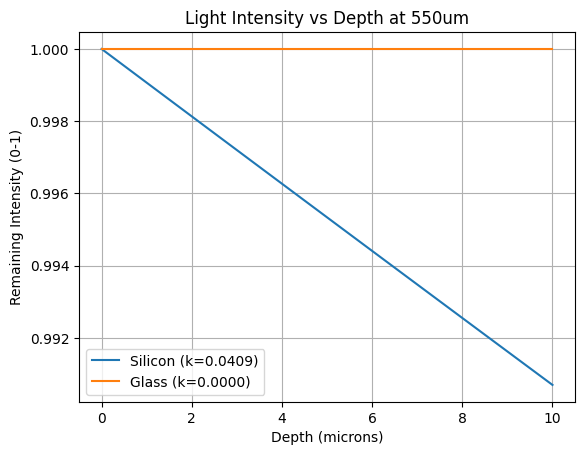

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from refractiveindex import RefractiveIndexMaterial

# 1. Load Materials
# Note: Ensure you have the database or library installed
silicon = RefractiveIndexMaterial(shelf='main', book='Si', page='Aspnes')
glass = RefractiveIndexMaterial(shelf='3d', book='glass', page='BK7')

# 2. Define parameters
wavelength = 550 # 550 nm (Green light) in microns
thickness_microns = np.linspace(0, 10, 100) # 0 to 10 microns depth
theta1_deg = 45
theta1_rad = math.radians(theta1_deg)

# 3. Get k (extinction coefficient)
k_si = silicon.get_extinction_coefficient(wavelength)
k_glass = glass.get_extinction_coefficient(wavelength)

# Build complex indices N = n + i k
n1 = silicon.get_refractive_index(wavelength)
k1 = silicon.get_extinction_coefficient(wavelength)
N1 = complex(n1, k1)

n2 = glass.get_refractive_index(wavelength)
k2 = glass.get_extinction_coefficient(wavelength)
N2 = complex(n2, k2)

# Complex Snell
argument = (N1 / N2) * math.sin(theta1_rad)

# Use cmath.asin for complex arguments
theta2_rad = cmath.asin(argument)
theta2_deg = theta2_rad * (180 / math.pi)

print("N1 =", N1)
print("N2 =", N2)
print("theta2 (rad) =", theta2_rad)
print("theta2 (deg) =", theta2_deg)

# 4. Calculate Intensity (Beer-Lambert Law)
# Formula: I = I0 * exp(-4 * pi * k * z / wavelength)
def get_intensity(k_val, z_depths, w_len):
    alpha = (4 * np.pi * k_val) / w_len
    return np.exp(-alpha * z_depths)

intensity_si = get_intensity(k_si, thickness_microns, wavelength)
intensity_glass = get_intensity(k_glass, thickness_microns, wavelength)

# 5. Plot
plt.plot(thickness_microns, intensity_si, label=f'Silicon (k={k_si:.4f})')
plt.plot(thickness_microns, intensity_glass, label=f'Glass (k={k_glass:.4f})')
plt.title(f'Light Intensity vs Depth at {wavelength}um')
plt.xlabel('Depth (microns)')
plt.ylabel('Remaining Intensity (0-1)')
plt.legend()
plt.grid(True)
plt.show()

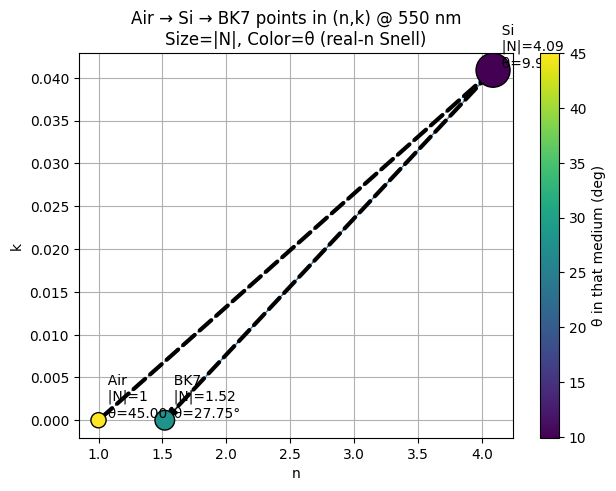

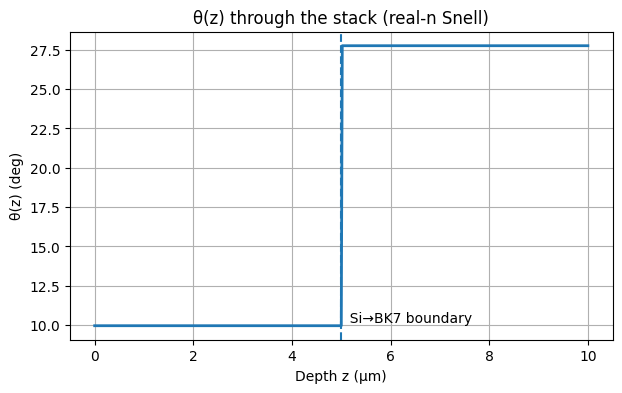

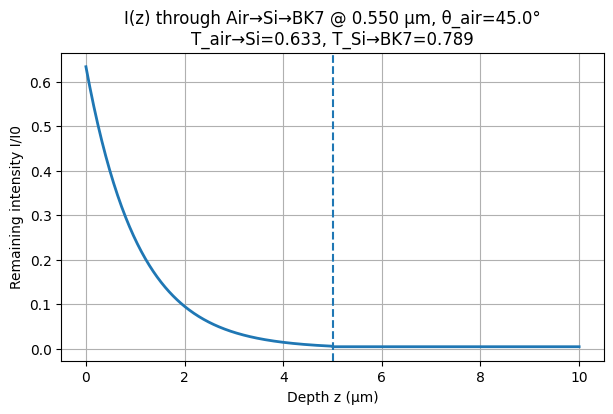

---- Material values @ 550 nm ----
Air   : n=1, k=0
Si    : n=4.08696,  k=0.0408816
BK7   : n=1.51852, k=7.23501e-09
---- Angles (real-n Snell) ----
theta_air = 45.000 deg
theta_Si  = 9.963 deg
theta_BK7 = 27.753 deg
---- Interface (unpolarized) ----
Air→Si  : R=0.3667, T=0.6333
Si→BK7  : R=0.2108, T=0.7892


In [5]:
import numpy as np
import cmath
import math
import matplotlib.pyplot as plt
from refractiveindex import RefractiveIndexMaterial

# ============================================================
# Fresnel (complex indices) + simple Beer–Lambert through stack
# ============================================================

def fresnel_RT(N1, N2, theta1_deg):
    """
    Fresnel power coefficients for an interface with possibly complex indices N1, N2.
    Returns: (T_unpol, R_unpol, R_s, R_p, T_s, T_p, theta2_rad)
    """
    theta1_rad = math.radians(theta1_deg)
    sin1 = math.sin(theta1_rad)
    cos1 = math.cos(theta1_rad)

    # Complex Snell: N1 sinθ1 = N2 sinθ2
    sin2 = (N1 / N2) * sin1
    theta2_rad = cmath.asin(sin2)
    cos2 = cmath.cos(theta2_rad)  # consistent branch with theta2_rad

    # Fresnel amplitude coefficients
    r_s = (N1 * cos1 - N2 * cos2) / (N1 * cos1 + N2 * cos2)
    r_p = (N2 * cos1 - N1 * cos2) / (N2 * cos1 + N1 * cos2)

    t_s = (2 * N1 * cos1) / (N1 * cos1 + N2 * cos2)
    t_p = (2 * N1 * cos1) / (N2 * cos1 + N1 * cos2)

    # Power reflectance
    R_s = abs(r_s) ** 2
    R_p = abs(r_p) ** 2

    # Power transmittance (Poynting flux ratio)
    denom = (N1 * cos1).real
    if abs(denom) < 1e-15:
        T_s = float("nan")
        T_p = float("nan")
    else:
        factor = (N2 * cos2).real / denom
        T_s = factor * abs(t_s) ** 2
        T_p = factor * abs(t_p) ** 2

    R_unpol = 0.5 * (R_s + R_p)
    T_unpol = 0.5 * (T_s + T_p)

    return T_unpol, R_unpol, R_s, R_p, T_s, T_p, theta2_rad


def theta_in_medium_real_n(theta_air_rad, n_air, n_med):
    """Real-n Snell for geometry/path-length: n_air sinθ_air = n_med sinθ_med"""
    s = n_air * math.sin(theta_air_rad) / n_med
    s = max(-1.0, min(1.0, s))
    return math.asin(s)


# ----------------------
# User-controlled inputs
# ----------------------
wavelength_nm = 550
theta_air_deg = 45.0

t_total_um = 10.0
t_si_um = 5.0
t_bk7_um = t_total_um - t_si_um

m1 = 250  # points in Si region
m2 = 250  # points in BK7 region

# ----------------------
# Materials from library
# ----------------------
silicon = RefractiveIndexMaterial(shelf="main", book="Si", page="Aspnes")
glass   = RefractiveIndexMaterial(shelf="3d", book="glass", page="BK7")  # adjust if needed

# --------------------------------
# Units and basic incident settings
# --------------------------------
wavelength_um = wavelength_nm / 1000.0
theta_air_rad = math.radians(theta_air_deg)

# Complex indices (N = n + i k)
n_air, k_air = 1.0, 0.0
N_air = complex(n_air, k_air)

n_si  = float(silicon.get_refractive_index(wavelength_nm))
k_si  = float(silicon.get_extinction_coefficient(wavelength_nm))
N_si  = complex(n_si, k_si)

n_bk7 = float(glass.get_refractive_index(wavelength_nm))
k_bk7 = float(glass.get_extinction_coefficient(wavelength_nm))
N_bk7 = complex(n_bk7, k_bk7)

# -------------------------------
# Build depth axis and piecewise n,k
# -------------------------------
z1 = np.linspace(0, t_si_um, m1)              # inside Si (includes boundary)
z2 = np.linspace(t_si_um, t_total_um, m2)[1:] # inside BK7 (skip duplicate boundary)
z = np.concatenate([z1, z2])

n_z = np.concatenate([np.full_like(z1, n_si),  np.full_like(z2, n_bk7)])
k_z = np.concatenate([np.full_like(z1, k_si),  np.full_like(z2, k_bk7)])

# Index where BK7 begins in the concatenated z array
idx_bk7_start = len(z1)  # first point in BK7 region (z[idx_bk7_start] > t_si_um)

# -------------------------------
# Angle profile θ(z) (real-n Snell)
# -------------------------------
sin_const = n_air * math.sin(theta_air_rad)
arg = sin_const / n_z
arg = np.clip(arg, -1.0, 1.0)
theta_z_rad = np.arcsin(arg)              # radians, len(z)
theta_z_deg = np.degrees(theta_z_rad)     # degrees, len(z)

# Angles in each medium (real-n Snell, for labeling & oblique path length)
theta_si_rad  = theta_in_medium_real_n(theta_air_rad, n_air, n_si)
theta_bk7_rad = theta_in_medium_real_n(theta_air_rad, n_air, n_bk7)
theta_si_deg  = math.degrees(theta_si_rad)
theta_bk7_deg = math.degrees(theta_bk7_rad)

# ---------------------------------------
# Interface transmissions (unpolarized)
# ---------------------------------------
T_air_si, R_air_si, *_ = fresnel_RT(N_air, N_si, theta_air_deg)

# For Si -> BK7 interface, the incident angle is the angle inside Si (real-n approx)
# (This is a common approximation for geometry; Fresnel uses complex N's.)
T_si_bk7, R_si_bk7, *_ = fresnel_RT(N_si, N_bk7, theta_si_deg)

# ---------------------------------------
# Beer–Lambert intensity through stack
# Includes:
#   - transmission into Si at z=0 (T_air_si)
#   - absorption along oblique path (ds = dz / cos(theta))
#   - transmission Si->BK7 at boundary
# ---------------------------------------
I = np.ones_like(z, dtype=float)
I[0] = float(T_air_si)  # intensity just inside Si after first interface

dz = np.diff(z, prepend=z[0])

for i in range(1, len(z)):
    # Apply interface transmission at the first BK7 point
    if i == idx_bk7_start:
        I[i-1] *= float(T_si_bk7)

    # Beer–Lambert in current medium, with oblique path correction
    alpha = (4 * math.pi * k_z[i]) / wavelength_um       # 1/um
    cos_th = float(np.cos(theta_z_rad[i]))
    cos_th = max(1e-12, cos_th)
    ds = dz[i] / cos_th
    I[i] = I[i-1] * math.exp(-alpha * ds)
    

# ---------------------------------------
# Plot 1: points (n,k) for Air, Si, BK7
# Size = |N|, Color = θ in that medium (deg)
# ---------------------------------------
labels = ["Air", "Si", "BK7"]
n_pts = np.array([n_air, n_si, n_bk7], dtype=float)
k_pts = np.array([k_air, k_si, k_bk7], dtype=float)

Nmag = np.sqrt(n_pts**2 + k_pts**2)
s_min, s_max = 120, 600
sizes = s_min + (Nmag - Nmag.min()) / max(1e-12, (Nmag.max() - Nmag.min())) * (s_max - s_min)

theta_deg_media = np.array([theta_air_deg, theta_si_deg, theta_bk7_deg], dtype=float)

plt.figure(figsize=(7, 5))
plt.plot(n_pts, k_pts, linestyle="--", linewidth=1)

for i in range(len(n_pts) - 1):
    plt.annotate(
        "", xy=(n_pts[i+1], k_pts[i+1]), xytext=(n_pts[i], k_pts[i]),
        arrowprops=dict(arrowstyle="->", linestyle="--", lw=3)
    )

sc = plt.scatter(n_pts, k_pts, s=sizes, c=theta_deg_media, edgecolors="k", zorder=3)
plt.colorbar(sc, label="θ in that medium (deg)")

for i, lab in enumerate(labels):
    plt.text(
        n_pts[i], k_pts[i],
        f"  {lab}\n  |N|={Nmag[i]:.3g}\n  θ={theta_deg_media[i]:.2f}°",
        va="bottom"
    )

plt.title(f"Air → Si → BK7 points in (n,k) @ {wavelength_nm} nm\nSize=|N|, Color=θ (real-n Snell)")
plt.xlabel("n")
plt.ylabel("k")
plt.grid(True)
plt.show()

# ---------------------------------------
# Plot 2: θ(z) vs depth
# ---------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(z, theta_z_deg, linewidth=2)
plt.axvline(t_si_um, linestyle="--")
plt.text(t_si_um, theta_z_deg[np.searchsorted(z, t_si_um)], "  Si→BK7 boundary", va="bottom")
plt.title("θ(z) through the stack (real-n Snell)")
plt.xlabel("Depth z (μm)")
plt.ylabel("θ(z) (deg)")
plt.grid(True)
plt.show()

# ---------------------------------------
# Plot 3: I(z) vs depth (includes interface T + absorption)
# ---------------------------------------
plt.figure(figsize=(7, 4))
plt.plot(z, I, linewidth=2)
plt.axvline(t_si_um, linestyle="--")
plt.title(
    f"I(z) through Air→Si→BK7 @ {wavelength_um:.3f} μm, θ_air={theta_air_deg}°\n"
    f"T_air→Si={T_air_si:.3f}, T_Si→BK7={T_si_bk7:.3f}"
)
plt.xlabel("Depth z (μm)")
plt.ylabel("Remaining intensity I/I0")
plt.grid(True)
plt.show()

# Optional: quick prints
print("---- Material values @", wavelength_nm, "nm ----")
print(f"Air   : n={n_air:.6g}, k={k_air:.6g}")
print(f"Si    : n={n_si:.6g},  k={k_si:.6g}")
print(f"BK7   : n={n_bk7:.6g}, k={k_bk7:.6g}")
print("---- Angles (real-n Snell) ----")
print(f"theta_air = {theta_air_deg:.3f} deg")
print(f"theta_Si  = {theta_si_deg:.3f} deg")
print(f"theta_BK7 = {theta_bk7_deg:.3f} deg")
print("---- Interface (unpolarized) ----")
print(f"Air→Si  : R={R_air_si:.4f}, T={T_air_si:.4f}")
print(f"Si→BK7  : R={R_si_bk7:.4f}, T={T_si_bk7:.4f}")


### Critical Angle
- The Critical Angle is a special "tipping point" angle at 90°. 
- Any angle of incidence greater than this, causes light to stop escaping the material and reflects entirely back inside, Total Internal Reflection (TIR).
- Only possibile when moving from a high index ($n_1$) to a low index ($n_2$) (e.g., Water $\to$ Air). 
### Angled Light reactions
- Small Angle: Light escapes into the air (refracts)
- Critical Angle: Light skims exactly along the surface (90° refraction). travels along the boundry @ this boundry most of the light is already reflecting 
- Large Angle: Light is trapped inside. The surface acts like a perfect mirror. Max amount of light is reflecting
- high contrast in indices cause reflections eitherway, but $\theta$ < 90° means max reflection of input light
    - this happens until we complete the circle so at 0 degrees we would go back to less than max



### Fresnel Equations
- Snell's Law tells you the direction direction and speed of light (n)
    - $n_1 \sin(\theta_1) = n_2 \sin(\theta_2)$
- Fresnel Equations tell you about the intensity, energy absorbed/transmitted (k)
    - $R = \frac{(n - 1)^2 + k^2}{(n + 1)^2 + k^2}$
    - $R$: The fraction of optical power reflected (0.0 to 1.0).
    - $n$: Refractive index of your material.
    - $k$: Extinction coefficient of your material.
    - 1: The approximate refractive index of Air (the medium the light is coming from).
- Normal Incidence
    - $k=0$ $\to$ no absoboartion
    - $\theta_i$ = 0 $\to$ light hitting the material straight on 


In [1]:
import numpy as np
from refractiveindex import RefractiveIndexMaterial

# 1. Define the Calculate Function
def calculate_reflectivity(n, k):
    numerator = (n - 1)**2 + k**2
    denominator = (n + 1)**2 + k**2
    return numerator / denominator

# 2. Load Materials
silicon = RefractiveIndexMaterial(shelf='main', book='Si', page='Aspnes')
glass = RefractiveIndexMaterial(shelf='3d', book='glass', page='BK7')
silver = RefractiveIndexMaterial(shelf='main', book='Ag', page='Johnson')

# 3. Choose a Wavelength (e.g., 550nm - Green Light)
wavelength = 550

# 4. Get Data & Calculate
materials = {"Silicon": silicon, "Glass": glass, "Silver": silver}

print(f"Reflectivity at {wavelength*1000}nm (Green Light):")
print("-" * 40)

for name, material in materials.items():
    n = material.get_refractive_index(wavelength)
    k = material.get_extinction_coefficient(wavelength)
    
    # Calculate R
    R = calculate_reflectivity(n, k)
    
    # Convert to Percentage
    print(f"{name:10} | n={n:.3f}, k={k:.3f} | Reflectivity: {R*100:.2f}%")

Reflectivity at 550000nm (Green Light):
----------------------------------------
Silicon    | n=4.087, k=0.041 | Reflectivity: 36.83%
Glass      | n=1.519, k=0.000 | Reflectivity: 4.24%
Silver     | n=0.060, k=3.597 | Reflectivity: 98.31%


Material        | Index (n)  | Reflectivity (R)
---------------------------------------------
Water           | 1.33       | 2.01%
Glass (BK7)     | 1.52       | 4.26%
Cubic Zirconia  | 2.15       | 13.33%
Diamond         | 2.42       | 17.24%
Moissanite      | 2.65       | 20.44%


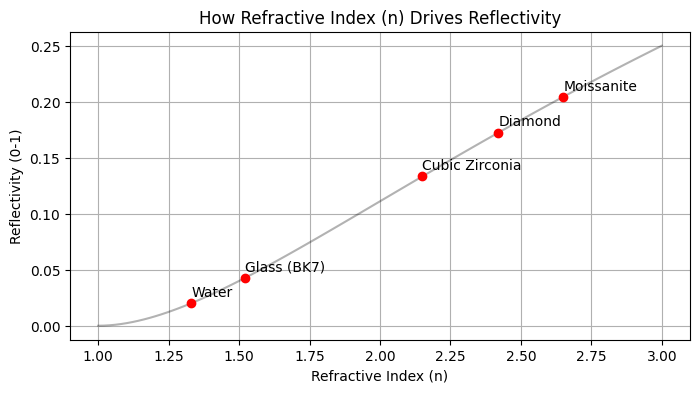

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Wavelength (We must choose one!)
# Let's use 589 nm (Sodium yellow light), standard for gemology.
wavelength = 550

# 2. Define our materials by their Index (n) manually
# (Assuming k=0 for all of them to isolate the effect of n)
materials = {
    "Water": 1.33,
    "Glass (BK7)": 1.52,
    "Cubic Zirconia": 2.15,
    "Diamond": 2.42,
    "Moissanite": 2.65
}

# 3. Calculate Reflectivity based ONLY on n
print(f"{'Material':<15} | {'Index (n)':<10} | {'Reflectivity (R)':<15}")
print("-" * 45)

n_values = []
r_values = []

for name, n in materials.items():
    # Simplified Fresnel Equation (k=0)
    R = ((n - 1) / (n + 1)) ** 2
    
    n_values.append(n)
    r_values.append(R)
    print(f"{name:<15} | {n:<10.2f} | {R*100:.2f}%")

# 4. Plotting the curve
ns = np.linspace(1.0, 3.0, 100)
Rs = ((ns - 1) / (ns + 1)) ** 2

plt.figure(figsize=(8, 4))
plt.plot(ns, Rs, color='black', alpha=0.3)
plt.scatter(n_values, r_values, color='red', zorder=5)

# Label the points
for i, txt in enumerate(materials.keys()):
    plt.annotate(txt, (n_values[i], r_values[i]), xytext=(0, 5), textcoords='offset points')

plt.title("How Refractive Index (n) Drives Reflectivity")
plt.xlabel("Refractive Index (n)")
plt.ylabel("Reflectivity (0-1)")
plt.grid(True)
plt.show()

## Reflection Coefficient of angled light

- s-polarization (strong reflection) (perpendicular to electric field) electric field vector is oriented at a right angle to the direction in which the wave is traveling and the surface it’s interacting with 
- p-polarization (weak reflection) (parallel to electric field) P-polarization means that the electric field lies within that plane of incidence
$$r_s =  \frac{n_1 \cos(\theta_i) - n_2 \cos(\theta_t)}{n_1 \cos(\theta_i) + n_2 \cos(\theta_t)}, r_p = \frac{n_1 \cos(\theta_t) - n_2 \cos(\theta_i)}{n_1 \cos(\theta_t) + n_2 \cos(\theta_i)} $$
 
## Transmission

$$t_s = \frac{2n_1 \cos \theta_i}{n_1 \cos \theta_i + n_2 \cos \theta_t}, t_p = \frac{2n_1 \cos \theta_i}{n_2 \cos \theta_i + n_1 \cos \theta_t}$$

## Amplitude to Reflectance (Power)

Reflectance ($R$) represents the fraction of optical power reflected
For polarized light:$$R_s = |r_s|^2, \quad R_p = |r_p|^2$$
- $r$ (Amplitude Reflection Coefficient): This tracks the Electric Field. It tells you how the wave wiggles (Up/Down) after hitting the wall. It can be positive, negative, or complex.
- $R$ (Reflectivity): This tracks the Energy/Brightness. It is simply the square of $r$ ($R = |r|^2$). It is always positive.
    - When you calculate $R$, you square the number. If $r = +-0.5$, then $R = 0.25$.
    - $R$ is the same in both cases! The information lost is the negative sign. That negative sign is the phase shift.
For unpolarized light:$$R = \frac{R_s + R_p}{2}$$

In [9]:
import numpy as np
import cmath
import math
from refractiveindex import RefractiveIndexMaterial

def fresnel_RT(N1, N2, theta1_deg):
    """
    Fresnel power coefficients for an interface with possibly complex indices n1, n2.
    Returns: (T_unpol, R_unpol, R_s, R_p, T_s, T_p, theta2_rad)
    """
    theta1_rad = math.radians(theta1_deg)
    sin1 = math.sin(theta1_rad)
    cos1 = math.cos(theta1_rad)

    # Snell: n1 sinθ1 = n2 sinθ2  -> sinθ2 = (n1/n2) sinθ1
    sin2 = (N1 / N2) * sin1
    theta2_rad = cmath.asin(sin2)
    
    # Use cmath.asin for complex arguments
    cos2 = cmath.cos(theta2_rad)

    # Fresnel amplitude reflection coefficients
    r_s = (N1 * cos1 - N2 * cos2) / (N1 * cos1 + N2 * cos2)
    r_p = (N2 * cos1 - N1 * cos2) / (N2 * cos1 + N1 * cos2)

    # Fresnel amplitude transmission coefficients
    t_s = (2 * N1 * cos1) / (N1 * cos1 + N2 * cos2)
    t_p = (2 * N1 * cos1) / (N2 * cos1 + N1 * cos2)

    # Power reflectance
    R_s = abs(r_s)**2
    R_p = abs(r_p)**2

    # Power transmittance (Poynting flux ratio)
    denom = (N1 * cos1).real
    if abs(denom) < 1e-15:
        T_s = float("nan")
        T_p = float("nan")
    else:
        factor = (N2 * cos2).real / denom
        T_s = factor * abs(t_s)**2
        T_p = factor * abs(t_p)**2

    R_unpol = 0.5 * (R_s + R_p)
    T_unpol = 0.5 * (T_s + T_p)

    return T_unpol, R_unpol, R_s, R_p, T_s, T_p, theta2_rad

# --- Example usage ---
theta_inc = 45.0
N1 = 1.0 + 0.0j

# Materials
silicon = RefractiveIndexMaterial(shelf='main', book='Si', page='Aspnes')
glass   = RefractiveIndexMaterial(shelf='3d',   book='glass', page='BK7')     # keep your choice
silver  = RefractiveIndexMaterial(shelf='main', book='Ag', page='Johnson')

wavelength_nm = 550  # nm

materials = {"Silicon": silicon, "Glass": glass, "Silver": silver}

for name, material in materials.items():
    n = material.get_refractive_index(wavelength_nm)
    k = material.get_extinction_coefficient(wavelength_nm)
    N2 = complex(n, k)

        
    T, R, R_s, R_p, T_s, T_p, theta2_rad = fresnel_RT(N1, N2, theta_inc)
    
    print(f"{name:8} | n={N2.real:.3f}, k={N2.imag:.3f} | "
        f"R={R*100:6.2f}%  Rs={R_s*100:6.2f}% Rp={R_p*100:6.2f}% | "
        f"T={T*100:6.2f}%  Ts={T_s*100:6.2f}% Tp={T_p*100:6.2f}%  | "
        f"θ2≈{math.degrees(theta2_rad.real):6.2f}° + i{math.degrees(theta2_rad.imag):.2f}°")


Silicon  | n=4.087, k=0.041 | R= 36.67%  Rs= 49.17% Rp= 24.17% | T= 63.33%  Ts= 50.83% Tp= 75.83%  | θ2≈  9.96° + i-0.10°
Glass    | n=1.519, k=0.000 | R=  5.28%  Rs=  9.64% Rp=  0.93% | T= 94.72%  Ts= 90.36% Tp= 99.07%  | θ2≈ 27.75° + i-0.00°
Silver   | n=0.060, k=3.597 | R= 98.24%  Rs= 98.82% Rp= 97.66% | T=  1.68%  Ts=  1.18% Tp=  2.18%  | θ2≈  0.18° + i-11.19°


### Phase Shift
- The "Phase Shift" is the hidden variable in the Fresnel Equations. While the Reflectivity ($R$) tells you how bright the reflection is, the Phase tells you the timing of the wave.
- This timing flip allows Anti-Reflective (AR) coatings to "delete" reflections by canceling the wave out.
- Air ($n=1.0$) $\to$ Glass ($n=1.5$): The light hits a "harder" medium.
    - Result: The reflected wave flips upside down (180° shift).
- Glass ($n=1.5$) $\to$ Air ($n=1.0$): The light hits a "softer" medium.
    - Result: The reflected wave stays upright (No shift).

### Anti-Reflective Coatings

- An Anti-Reflective (AR) coating is essentially a "light trap" designed for a specific color. By choosing the thickness carefully, we force the light reflecting off the top surface to destructively interfere with the light reflecting off the bottom surface.
- Destructive Interference
- For an AR coating to work, two conditions must be met:
    1. Amplitude Matching: The reflection from the top (Air $\to$ Coating) must be roughly equal in strength to the reflection from the bottom (Coating $\to$ Glass). Ideally, $n_{coating} \approx \sqrt{n_{air} \times n_{glass}}$
    2. .Phase Matching: The coating thickness must be exactly $\lambda / 4$ (Quarter Wave) so the second wave is delayed by half a cycle ($\lambda / 2$) relative to the first.
    -In L.I.G.O. detecors instead of one layer, layers are used with contrasting refractive indices.
    1. Inner Layer (Touching Glass): High Index (e.g., Zirconia, $n \approx 2.1$).
    2. Outer Layer (Touching Air): Low Index (e.g., Magnesium Fluoride, $n \approx 1.38$).
    - By adjusting the thickness of these two layers, we can create a complex interference pattern where the reflection from the first, second, and third interfaces all cancel each other out perfectly at exactly one wavelength.
- If you want to stop glass from reflecting: You coat the glass with a thin film. This 180° flip is the key to making invisible glass.
    - Ray A: Reflects off top (Air $\to$ Film).
    - Ray B: Enters film, reflects off bottom, exits film.
- Tracking the Phase Shifts (The Scorecard)
    - Ray A (Top Reflection)
    - Bounce: Hit "hard" surface (Air < Film). $\rightarrow$ Add 180°.
    - Travel: None. $\rightarrow$ Add 0°.
- TOTAL PHASE A: 180° (Imagine this points DOWN).
    - Ray B (Bottom Reflection)
    - Bounce: Hit "hard" surface (Film < Glass). $\rightarrow$ Add 180°.
    - Travel: Down $\lambda/4$ + Up $\lambda/4$ = $\lambda/2$. $\rightarrow$ Add 180°.
- TOTAL PHASE B: $180^\circ + 180^\circ =$ 360° (This resets to 0°). (Imagine this points UP).
    - The Collision (At the Surface)
    - Ray A: Phase 180° (Valley / -1)
    - Ray B: Phase 360°/0° (Peak / +1)Result: $(-1) + (+1) = 0$.

## Examples 

- Fresnel Equation for hitting a surface straight on, Normal Incidence: 
    - $r = \frac{n_1 - n_2}{n_1 + n_2}$

- Scenario A: Air ($1.0$) $\to$ Glass ($1.5$)
    $r = \frac{1.0 - 1.5}{1.0 + 1.5} = \frac{-0.5}{2.5} = \mathbf{-0.2}$
    - Result: The coefficient is Negative. A "Negative Amplitude" means the wave flips upside down.
    - Math: In trigonometry, $-\sin(x)$ is identical to $\sin(x + 180^\circ)$.
    - Phase Shift: $180^\circ$ (or $\pi$).

- Scenario B: Glass ($1.5$) $\to$ Air ($1.0$)
    $r = \frac{1.5 - 1.0}{1.5 + 1.0} = \frac{0.5}{2.5} = \mathbf{+0.2}$
    - Result: The coefficient is Positive. The wave bounces back upright.
    - Phase Shift: $0^\circ$.

- "Negative Amplitude"
    - Why do we call a negative number a "180-degree shift"? It comes from the Unit Circle on the Complex Plane.
    - Imagine a clock face (The Complex Plane):
    - 3 o'clock ($+1$): This is $0^\circ$. (Positive Real numbers).
    - 9 o'clock ($-1$): This is $180^\circ$. (Negative Real numbers).
    - When the Fresnel equation gives you a negative number (like $-0.2$), you are pointing to the left on the graph—at 9 o'clock. The "angle" of that pointer is $180^\circ$.


- Brewster's Angle There is a specific angle where the math for $R_p$ does something magic: the numerator becomes zero.
$$R_p = 0$$
- At this angle, 100% of the P-polarized light passes through. There is absolutely no P-reflection. reflected and transmitted angles are 90 degrees this is like polarizers

- this means we percieve 100 % of s-polariztiion light since this is all the light being reflected as all of p passes through

## Metals?
Machine learning model will need the full "Complex Number" approach.
If you reflect off Gold, $n$ is not just a simple number; it has a $k$ (absorption) component: $\tilde{n} = 0.2 + 3.0i$.
If you plug a complex number into that simple Fresnel fraction:
$$r = \frac{1 - (0.2 + 3.0i)}{1 + (0.2 + 3.0i)}$$
The result $r$ will be a complex number, something like:
$$r \approx -0.9 + 0.1i$$
Now, the pointer on the clock isn't at 3:00 or 9:00. It might be pointing at 135°.
This means the wave doesn't just "flip" or "stay"; it lags.
The wave bounces back, but it is slightly delayed compared to a perfect mirror.

### Cavity Optics
- LIGO detectors, use Fabry–Pérot arm cavities, so the coating isn’t just “make it shiny”, it has to hit cavity-driven constraints. 

1) The cavity sets the required reflectivity and transmission

    - For a Fabry–Pérot cavity, the finesse (how many effective bounces / how narrow the resonance is) is controlled by mirror reflectivity + total round-trip loss. Higher reflectivity (and lower loss) → higher finesse. 

    - Advanced LIGO chose an arm cavity finesse ~450, which corresponds (roughly) to an ITM transmission ~1.4% as part of that trade space. 

    - Coating design (R and T) is literally a cavity parameter. This will be a hardcoded parameter we cant change much

2) High finesse + high stored power makes absorption a coating-limiting issue

    - Cavities in Advanced LIGO store very large circulating power (order of hundreds of kW), which makes even “tiny” absorption matter because it causes heating, thermal lensing, and surface deformation. 

    - LIGO coatings are engineered for extremely low absorption (notes silica + titania-doped tantala coatings with absorption < ~0.4 ppm). 

3) Cavity sensitivity is limited by coating thermal noise, which depends on coating material + thickness

    - Mirrors must be high-reflectivity, higher R usually means more layers / thicker coatings → increases coating Brownian thermal noise

    - Optical Demands: high R, low scatter, low absorption (to keep finesse and power build-up high)

    - Mechanical Demands: low loss angle + minimal thickness (to keep thermal noise low)

    - High/low index pairs (silica + titania-doped tantala) helps reach high reflectivity with fewer layers. 

4) The cavity also cares about losses and “stray light”

    - Scattering and other losses waste power

    - in an interferometer they can create parasitic fields that add noise and reduce contrast. Cavity designs therefore impose ppm-level goals on scatter/absorption and transmission matching. 

5) It even influences what “next-gen” coatings look like

    - Cavity performance is limited by coating thermal noise, for improvments we mus look at new coating materials/approaches (crystalline AlGaAs/GaAs, low-loss stacks) aimed at lowering mechanical loss while keeping optical loss tiny. 

1) Optical side: n,k → Fresnel + Bragg stack → 𝑅,𝑇 (and loss)

- Each material is described by a complex refractive index 𝑁 = 𝑛 + 𝑖𝑘 
- At a single interface (normal incidence, k, theta = 0), reflectance is essentially

$$R = \left|\frac{N_1 - N_2}{N_1 + N_2}\right|^2$$

- and  $k$ drives absorption via

$$\alpha = \frac{4\pi k}{\lambda}$$

A Bragg/DBR stack (alternating high/low index layers) uses interference to get extremely high reflectivity at the design wavelength. Reflectivity depends strongly on index contrast and number of pairs. 
 
2) Cavity optics forces specific $𝑇$ (not “maximize R everywhere”)

For LIGO’s arm cavities, the mirror coatings are chosen to hit particular transmissions and losses because that sets cavity behavior (finesse, linewidth, stored power, control robustness). Advanced LIGO’s arm cavity finesse ~450 is part of that trade space. 

The loss budget is ppm-level and includes scatter, absorption, and (for the ETM) a tiny transmission. 

So you’ll design ITM vs ETM coatings differently:

ITM: intentionally “leaky” (higher $𝑇$) to set the cavity coupling.

ETM: extremely high %𝑅%, tiny %𝑇%, ultra-low scatter/absorption. 

3) Robustness: thickness errors and index uncertainty

What you called “robustness” is real and important: you want $𝑅(𝜆)$, $𝑇(𝜆)$, and phase to be insensitive to realistic deposition errors.

Two common ways people quantify it:

Sensitivity/gradients: 
$∂𝑅/∂𝑡_𝑖$ layer-by-layer, worst-case and RMS.

Monte Carlo tolerancing: randomly perturb each layer thickness (e.g., ±0.5–1%) and see the distribution of $𝑅,𝑇$, stopband shift, and phase. (Quarter-wave stacks are often fairly tolerant, but you still must check.) 

4) Absorption → heating → thermal lensing/expansion (and more)

You’re right: low absorption matters because high circulating power makes tiny ppm absorption turn into real heat and deformation. Advanced LIGO design documents explicitly allocate ppm-level absorption in the loss budget. 

5) Brownian coating thermal noise is tied to the stack (and often dominates)

Also correct: coating Brownian noise depends on the mechanical loss of coating materials and roughly scales with effective coating thickness and elastic properties — so a “more pairs = better R” approach can make noise worse. This is why people optimize layer thicknesses (sometimes not strict quarter-wave) to reduce thermal noise while keeping the needed $𝑇/𝑅$.

6) A few “must-add” constraints beyond what you listed

Scatter/roughness (dominant contributor to cavity loss in practice). 

Thermo-optic noise (thermorefractive + thermoelastic in coatings) — separate from Brownian noise (often discussed alongside it in coating-noise overviews). 

Process constraints: annealing, crystallization risk, stress/curvature, coating defects; many R&D efforts focus on material tweaks (e.g., doped tantala variants, ternary stacks, etc.). 

A practical design workflow

Fix wavelength (e.g., 1064 nm for aLIGO; 1550 nm is common in next-gen concepts).

Set cavity requirements: target finesse/coupling → required ITM/ETM $𝑇$, allowed round-trip loss, acceptable phase. 

Pick candidate materials with measured $𝑛(𝜆), 𝑘(𝜆)$ and mechanical loss. 

Optimize the stack for optical goals + coating thermal noise. 

Run tolerances (your robustness step): thickness + index uncertainty + angle/polarization sensitivity. 

Check absorption → thermal distortion; check scatter budget. 
